# Chapter 40: Knowledge Distillation

**Do soft teacher targets beat hard labels for a small neural student, or does that depend on how well the hard-label baseline is tuned?**

A distilled student can look like a large win against an untuned hard-label baseline. The chapter asks for the hard-label endpoint of alpha to stay in the comparison and for the student to be judged on genuine held-out labels.

*Constructed data, one noise level and one student. Soft targets slow overfitting but did not beat an early-stopped hard-label student here; a result in the other direction would need its own evidence.*

## The experiment

A constructed binary task with 375 training and 125 development rows whose labels are flipped at 20%, and 6,000 test rows with unflipped labels. The teacher is a 60-tree random forest; its cross-fitted probabilities (5 folds) are the soft targets. The student is a small neural network (833 parameters) trained on alpha times the soft target plus (1 - alpha) times the hard label with soft cross-entropy, for alpha 0 (hard only), 0.5 and 1 (pure). The control is the number of epochs allowed. Each student is scored after its last epoch and at the epoch with the best development log loss. Results are means over 5 worlds.

In [1]:
import warnings

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPClassifier

from kaggle_companion.activities._common import clean

warnings.filterwarnings("ignore")   # one-epoch warm-start fits warn about convergence by design
SEED = 40
REPLICATES = 5          # independent worlds per training budget; results are means over them
N_TRAIN, N_DEV, N_TEST, FEATURES = 375, 125, 6000, 8
FLIP = 0.2              # share of training and development labels flipped
EPS = 1e-4
ALPHAS = (0.0, 0.5, 1.0)  # weight on the teacher's soft target; 0 is hard labels only


def generate(n, rng):
    """Eight features and a bent, interacting true probability."""
    X = rng.normal(size=(n, FEATURES))
    z = 1.4 * np.sin(1.3 * X[:, 0]) + 0.9 * X[:, 1] * X[:, 2] + 0.8 * X[:, 3] - 0.7 * np.abs(X[:, 4]) + 0.3
    return X, 1 / (1 + np.exp(-1.5 * z))


def forest():
    return RandomForestClassifier(60, min_samples_leaf=5, random_state=0, n_jobs=1)


def train_student(X, target, X_dev, y_dev, X_test, epochs, seed):
    """Soft-target cross-entropy via duplicated rows: each row counts as a 1 with weight q and as a 0 with weight 1 - q.

    Returns test probabilities after the last epoch and at the epoch with the best development log loss (early stopping)."""
    X2, y2, w2 = np.vstack([X, X]), np.r_[np.ones(len(X)), np.zeros(len(X))], np.r_[target, 1 - target]
    net = MLPClassifier((32, 16), alpha=1e-3, max_iter=1, warm_start=True, learning_rate_init=0.01, batch_size=64, random_state=seed)
    best_loss, best_pred, best_epoch = np.inf, None, 0
    for epoch in range(1, epochs + 1):
        net.fit(X2, y2, sample_weight=w2)                      # one more epoch from the current weights
        if epoch % 3 == 0 or epoch == epochs:
            loss = log_loss(y_dev, np.clip(net.predict_proba(X_dev)[:, 1], EPS, 1 - EPS), labels=[0, 1])
            if loss < best_loss:
                best_loss, best_pred, best_epoch = loss, np.clip(net.predict_proba(X_test)[:, 1], EPS, 1 - EPS), epoch
    parameters = sum(w.size for w in net.coefs_) + sum(b.size for b in net.intercepts_)
    return np.clip(net.predict_proba(X_test)[:, 1], EPS, 1 - EPS), best_pred, best_epoch, parameters


def one_world(epochs, seed):
    rng = np.random.default_rng(seed)
    X, p = generate(N_TRAIN + N_DEV, rng)
    clean_y = (rng.random(len(p)) < p).astype(int)
    y = np.where(rng.random(len(p)) < FLIP, 1 - clean_y, clean_y)      # noisy labels for training and development
    X_test, p_test = generate(N_TEST, rng)
    y_test = (rng.random(N_TEST) < p_test).astype(int)                 # genuine, unflipped test labels
    X_tr, y_tr, X_dev, y_dev = X[:N_TRAIN], y[:N_TRAIN], X[N_TRAIN:], y[N_TRAIN:]

    soft = np.zeros(N_TRAIN)                                            # cross-fitted teacher: no row is predicted by a model that saw its label
    for fit, out in KFold(5, shuffle=True, random_state=0).split(X_tr):
        soft[out] = forest().fit(X_tr[fit], y_tr[fit]).predict_proba(X_tr[out])[:, 1]
    teacher = forest().fit(X_tr, y_tr)
    pred = np.clip(teacher.predict_proba(X_test)[:, 1], EPS, 1 - EPS)
    out = {"teacher": [log_loss(y_test, pred), roc_auc_score(y_test, pred)],
           "teacher_nodes": sum(t.tree_.node_count for t in teacher.estimators_)}
    for alpha in ALPHAS:
        target = np.clip(alpha * soft + (1 - alpha) * y_tr, 0, 1)
        last, tuned, epoch, parameters = train_student(X_tr, target, X_dev, y_dev, X_test, epochs, seed)
        out[alpha] = [log_loss(y_test, last), roc_auc_score(y_test, last), log_loss(y_test, tuned), roc_auc_score(y_test, tuned), epoch]
        out["student_parameters"] = parameters
    return out


def run(epochs):
    worlds = [one_world(epochs, SEED * 100 + r) for r in range(REPLICATES)]

    def avg(get):
        return float(np.mean([get(w) for w in worlds]))
    arms = {}
    for alpha in ALPHAS:
        arms[str(alpha)] = {"fixed_log_loss": avg(lambda w: w[alpha][0]), "fixed_auc": avg(lambda w: w[alpha][1]),
                            "stopped_log_loss": avg(lambda w: w[alpha][2]), "stopped_auc": avg(lambda w: w[alpha][3]),
                            "stopped_epoch": avg(lambda w: w[alpha][4])}
    return clean({
        "epochs": epochs, "arms": arms,
        "teacher": {"log_loss": avg(lambda w: w["teacher"][0]), "auc": avg(lambda w: w["teacher"][1])},
        "mixed_beats_hard_stopped": avg(lambda w: w[0.5][2] < w[0.0][2]),
        "pure_worse_than_hard_stopped": avg(lambda w: w[1.0][2] > w[0.0][2]),
        "teacher_nodes": avg(lambda w: w["teacher_nodes"]), "student_parameters": worlds[0]["student_parameters"],
        "flip": FLIP, "replicates": REPLICATES,
    })


## Measure it across the control

The control is **training epochs allowed**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch40 import explain

VALUES = [6, 15, 30, 45]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                6     15     30     45
Hard labels, last epoch     0.593  0.660  0.991  1.365
Mixed, last epoch           0.599  0.608  0.644  0.674
Hard labels, early-stopped  0.598  0.598  0.598  0.598
Mixed, early-stopped        0.605  0.602  0.602  0.602
Pure soft, early-stopped    0.627  0.625  0.627  0.628
Forest teacher              0.594  0.594  0.594  0.594


## Look at it

The figure shows the default setting, training epochs allowed = 30.

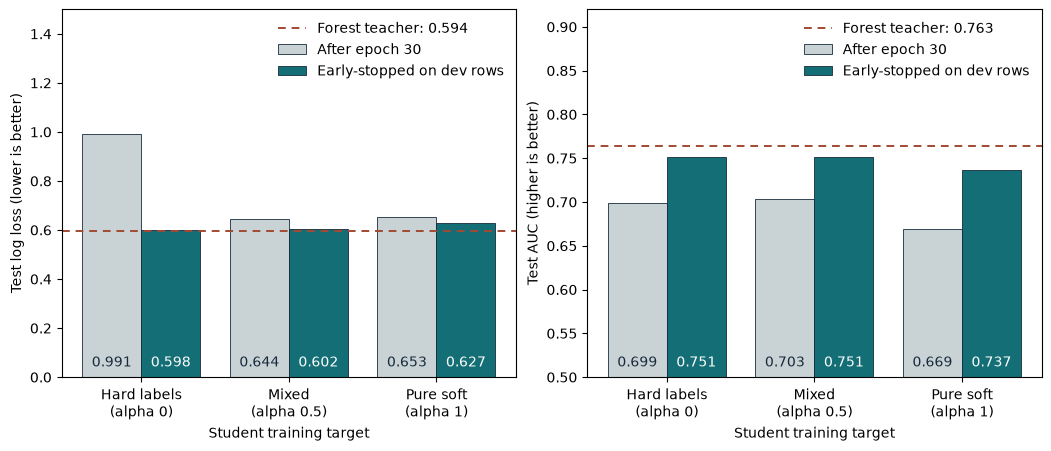

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch40 import draw, NCOLS, HEIGHT

DEFAULT = 30
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 30 epochs allowed and no early stopping, the hard-label student scores 0.991 and the half-soft student 0.644, a gain of 0.991 - 0.644 = +0.347. Early-stopped on development rows they score 0.598 and 0.602, a gain of 0.598 - 0.602 = -0.004. Pure soft targets score 0.627 early-stopped, and the forest teacher 0.594. The student has 833 parameters against about 4,109 tree nodes. The mixed student beat the hard-label student in 40% of 5 worlds once both were early-stopped.

- Apparent gain from soft targets, no early stopping: 0.991 - 0.644 = +0.347.
- Gain once both are early-stopped: 0.598 - 0.602 = -0.004.
- Pure soft against hard labels, early-stopped: 0.627 - 0.598 = +0.029.
- Tuned hard-label student against the teacher: 0.598 - 0.594 = +0.004.

## Apply this to your competition

- Always include alpha = 0 (hard labels only) and early stopping on development rows as the baseline before crediting soft targets.
- Generate teacher targets with cross-fitting inside each outer training partition; a teacher that saw a row's label leaks it into the student.
- Judge student, teacher and hard-label baseline on the same genuine labels, and report parameters or nodes and latency beside the loss.
- Prefer a mixed alpha chosen on development rows over pure distillation, and treat any gain as a hypothesis until the blend is assessed.

Book location: Chapter 40, GBM-to-NN Soft Label Distillation.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)